# Plancher de bruit : 0,02 g_rms / 500 Hz

La fiche technique du capteur piézoélectrique IEPE Kistler 8792A100 indique :

> **Plancher de bruit : 0,02 g_rms / 500 Hz**

Cette notation concentre deux informations :

- **0,02 g_rms** : le bruit est exprimé en valeur efficace (root mean square), en unité de g.
- **/ 500 Hz** : cette valeur est obtenue **en intégrant le bruit sur une bande de 0 à 500 Hz**. Ce n'est pas une densité par hertz.

Si l'on ne précisait pas la bande, la valeur serait sans signification physique : la puissance de bruit croît avec la bande observée.

---

## Modèle physique : bruit blanc

On suppose un **bruit blanc gaussien** : densité spectrale de puissance (DSP) constante sur toute la bande utile,

$$S_n = \text{const.} \quad [\text{g}^2/\text{Hz}]$$

La relation entre DSP et bruit efficace sur une bande $[0,\, B]$ est :

$$g_{\text{rms}}(B) = \sqrt{\int_0^B S_n \, df} = \sqrt{S_n \cdot B}$$

On en déduit la DSP à partir de la spec constructeur :

$$S_n = \frac{g_{\text{rms}}^2}{B} = \frac{(0{,}02)^2}{500} = 8 \times 10^{-7} \ \text{g}^2/\text{Hz}$$

On exprime aussi la **densité spectrale d'amplitude** (ASD, amplitude spectral density) en g/√Hz :

$$\text{ASD} = \sqrt{S_n} \approx 8{,}94 \times 10^{-4} \ \text{g}/\sqrt{\text{Hz}} \approx 0{,}89 \ \text{mg}/\sqrt{\text{Hz}}$$

C'est cette dernière grandeur que les constructeurs reportent parfois directement.

In [1]:
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt

# Spec constructeur
g_rms_spec = 0.02   # g_rms
BW_spec    = 500.0  # Hz (bande de reference de la spec)

# DSP du bruit (hypothese bruit blanc)
S_n = g_rms_spec**2 / BW_spec

print(f"DSP du bruit     : S_n = {S_n:.2e} g2/Hz")
print(f"Densite spectrale d'amplitude : sqrt(S_n) = {np.sqrt(S_n)*1e3:.2f} mg/sqrt(Hz)")
print(f"Verification     : sqrt(S_n x {BW_spec:.0f} Hz) = {np.sqrt(S_n * BW_spec)*1e3:.1f} mg_rms")

DSP du bruit     : S_n = 8.00e-07 g2/Hz
Densite spectrale d'amplitude : sqrt(S_n) = 0.89 mg/sqrt(Hz)
Verification     : sqrt(S_n x 500 Hz) = 20.0 mg_rms


## Simulation d'un signal de bruit

On génère un signal de bruit blanc discret à $f_e = 5\,000$ Hz
(fréquence d'échantillonnage maximale du SAVER 3X90),
dont la DSP correspond à la spec.

Pour un processus discret, la bande de Nyquist est $[0,\, f_e/2]$.
La variance du signal pleine bande est donc :

$$\sigma^2 = S_n \cdot \frac{f_e}{2}$$

L'écart-type $\sigma$ est plus grand que $g_{\text{rms}}$ sur 500 Hz
car la pleine bande de Nyquist est $f_e/2 = 2\,500$ Hz.

Ecart-type pleine bande (0–2500 Hz) : sigma = 44.7 mg
g_rms sur 500 Hz                       :        20.0 mg  (spec)
Rapport : sigma / g_rms(500Hz) = sqrt(2500/500) = 2.24


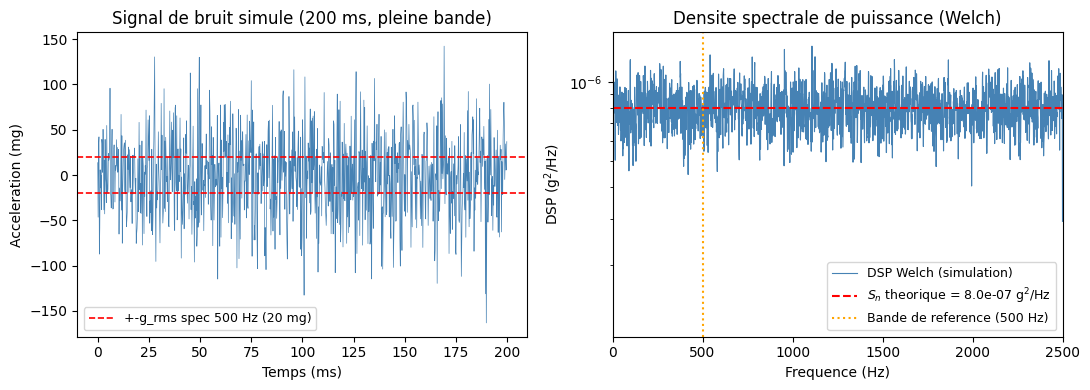

In [2]:
fe = 5000   # Hz — frequence d'echantillonnage
T  = 20.0   # duree de simulation (s)
N  = int(fe * T)

rng   = np.random.default_rng(42)
sigma = np.sqrt(S_n * fe / 2)       # ecart-type pleine bande Nyquist
bruit = rng.normal(0, sigma, N)
t     = np.arange(N) / fe

print(f"Ecart-type pleine bande (0–{fe//2} Hz) : sigma = {sigma*1e3:.1f} mg")
print(f"g_rms sur 500 Hz                       :        {g_rms_spec*1e3:.1f} mg  (spec)")
print(f"Rapport : sigma / g_rms(500Hz) = sqrt({fe//2}/{int(BW_spec)}) = {sigma/g_rms_spec:.2f}")

# DSP par methode de Welch — fenetre 1 s -> resolution Delta_f = 1 Hz
f_w, S_w = welch(bruit, fs=fe, nperseg=fe, window='hann', scaling='density')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# --- Signal temporel (200 ms) ---
n_show = int(0.2 * fe)
axes[0].plot(t[:n_show] * 1e3, bruit[:n_show] * 1e3, lw=0.5, color='steelblue')
axes[0].axhline( g_rms_spec * 1e3, color='red', ls='--', lw=1.2,
                 label=f'+-g_rms spec 500 Hz ({g_rms_spec*1e3:.0f} mg)')
axes[0].axhline(-g_rms_spec * 1e3, color='red', ls='--', lw=1.2)
axes[0].set_xlabel('Temps (ms)')
axes[0].set_ylabel('Acceleration (mg)')
axes[0].set_title('Signal de bruit simule (200 ms, pleine bande)')
axes[0].legend(fontsize=9)

# --- DSP ---
axes[1].semilogy(f_w, S_w, lw=0.8, color='steelblue', label='DSP Welch (simulation)')
axes[1].axhline(S_n, color='red', ls='--', lw=1.5,
                label=f'$S_n$ theorique = {S_n:.1e} g$^2$/Hz')
axes[1].axvline(BW_spec, color='orange', ls=':', lw=1.5,
                label=f'Bande de reference ({BW_spec:.0f} Hz)')
axes[1].set_xlabel('Frequence (Hz)')
axes[1].set_ylabel('DSP (g$^2$/Hz)')
axes[1].set_title('Densite spectrale de puissance (Welch)')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, fe / 2)

plt.tight_layout()
plt.show()

## Dependance vis-a-vis de la bande d'analyse

Le plancher de bruit **n'est pas une constante** : il depend de la bande sur laquelle on integre la DSP.

$$g_{\text{rms}}(B) = \sqrt{S_n \cdot B} = 0{,}02 \cdot \sqrt{\frac{B}{500}}$$

Plus la bande est large, plus on collecte de puissance de bruit — et inversement.

C'est le principe qui justifie la methode de Welch : en decoupant le signal en fenetres courtes,
on reduit la resolution spectrale $\Delta f$ (largeur d'un bin), et donc
le bruit apparent **par bin** :

$$g_{\text{rms, bin}} = \sqrt{S_n \cdot \Delta f}$$

Exemple avec $\Delta f = 1$ Hz :
$g_{\text{rms, bin}} = \sqrt{8 \times 10^{-7} \times 1} \approx 0{,}89$ mg par bin.

  Bande (Hz)    g_rms theo. (mg)    g_rms Welch (mg)
--------------------------------------------------------
           1                0.89                0.70
           5                2.00                2.06
          10                2.83                2.88
          50                6.32                6.37
         100                8.94                8.88
         200               12.65               12.59
         500               20.00               19.97  <-- spec constructeur
        1000               28.28               28.35
        2500               44.72               44.86


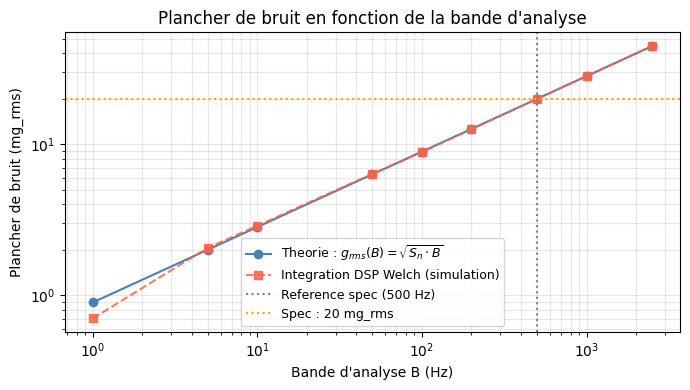

In [3]:
BW_arr = np.array([1, 5, 10, 50, 100, 200, 500, 1000, 2500])

# Theorie
g_rms_th = np.sqrt(S_n * BW_arr)

# Verification par integration de la DSP Welch
g_rms_welch = []
for BW in BW_arr:
    mask = f_w <= BW
    val  = np.trapezoid(S_w[mask], f_w[mask])
    g_rms_welch.append(np.sqrt(max(val, 0)))
g_rms_welch = np.array(g_rms_welch)

# Tableau
print(f"{'Bande (Hz)':>12}  {'g_rms theo. (mg)':>18}  {'g_rms Welch (mg)':>18}")
print("-" * 56)
for BW, g_th, g_w in zip(BW_arr, g_rms_th, g_rms_welch):
    flag = "  <-- spec constructeur" if BW == 500 else ""
    print(f"{BW:>12.0f}  {g_th*1e3:>18.2f}  {g_w*1e3:>18.2f}{flag}")

# Graphe
fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(BW_arr, g_rms_th * 1e3, 'o-', color='steelblue',
          label='Theorie : $g_{rms}(B) = \\sqrt{S_n \\cdot B}$')
ax.loglog(BW_arr, g_rms_welch * 1e3, 's--', color='tomato', alpha=0.85,
          label='Integration DSP Welch (simulation)')
ax.axvline(BW_spec, color='gray', ls=':', lw=1.5,
           label=f'Reference spec ({BW_spec:.0f} Hz)')
ax.axhline(g_rms_spec * 1e3, color='orange', ls=':', lw=1.5,
           label=f'Spec : {g_rms_spec*1e3:.0f} mg_rms')
ax.set_xlabel("Bande d'analyse B (Hz)")
ax.set_ylabel('Plancher de bruit (mg_rms)')
ax.set_title("Plancher de bruit en fonction de la bande d'analyse")
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Synthese

| Grandeur | Expression | Valeur (Kistler 8792A100) |
|---|---|---|
| Spec constructeur | $g_{\text{rms}}$ / $B_{\text{ref}}$ | 0,02 g / 500 Hz |
| DSP du bruit | $S_n = g_{\text{rms}}^2 / B_{\text{ref}}$ | $8 \times 10^{-7}$ g²/Hz |
| ASD | $\sqrt{S_n}$ | 0,89 mg/√Hz |
| Bruit pleine bande (0–2500 Hz) | $\sqrt{S_n \cdot f_e/2}$ | ~44,7 mg |
| Bruit par bin Welch ($\Delta f$ = 1 Hz) | $\sqrt{S_n \cdot \Delta f}$ | ~0,89 mg |

**A retenir :**

1. La spec "0,02 g_rms / 500 Hz" fixe la DSP : $S_n = 8 \times 10^{-7}$ g²/Hz.
2. Reduire la bande d'analyse reduit le plancher de bruit en $\sqrt{B}$.
3. La methode de Welch (fenetres courtes) exploite ce principe : chaque bin de 1 Hz
   a un plancher de ~0,89 mg, bien inferieur au plancher integre sur 500 Hz.
4. Le plancher du SAVER 3X90 (0,02 g_rms / 500 Hz) est coherent avec celui
   du Kistler 8792A100, ce qui valide leur compatibilite.